# Horizon Model Comparison

Loads the **best checkpoint** for each trained horizon (`configs/horizon_*.yaml` /
`checkpoints/horizon_*/best_model.pt`) and compares them on their respective held-out
test splits:

1. [Setup](#1.-Setup)
2. [Evaluate Each Horizon](#2.-Evaluate-Each-Horizon)
3. [Metrics Comparison](#3.-Metrics-Comparison)
4. [Confusion Matrices](#4.-Confusion-Matrices)
5. [Prediction Time Series (Up=Green / Down=Red)](#5.-Prediction-Time-Series)


---
## 1. Setup

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

from deeplob.config import load_config
from deeplob.dataset import build_datasets
from deeplob.evaluate import CLASS_NAMES, predict_indexed
from deeplob.logging_utils import get_logger
from deeplob.model import DeepLOB
from deeplob.test import run_test

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 11,
    }
)

logger = get_logger("horizon_comparison")


def pick_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


device = pick_device()
logger.info("device=%s", device)

2026-06-11 14:46:18,299 | INFO    | horizon_comparison | device=mps


---
## 2. Evaluate Each Horizon

In [2]:
# horizon name -> config/checkpoint name (configs/horizon_<name>.yaml, checkpoints/horizon_<name>/best_model.pt)
HORIZONS = {
    "1min": "horizon_1min",
    "2min": "horizon_2min",
    "5min": "horizon_5min",
    "10min": "horizon_10min",
}


def load_best_model(cfg, n_features, name, device):
    model = DeepLOB(n_features=n_features, n_classes=cfg.model.n_classes).to(device)
    path = os.path.join(cfg.paths.checkpoint_dir, name, "best_model.pt")
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    return model


results = {}
for label, name in HORIZONS.items():
    cfg = load_config(f"configs/{name}.yaml")
    datasets, n_features = build_datasets(cfg, logger)

    metrics = run_test(cfg, datasets["test"], n_features, device, logger, name)

    model = load_best_model(cfg, n_features, name, device)
    preds, targets, probs, index = predict_indexed(
        model,
        datasets["test"],
        device,
        batch_size=cfg.train.batch_size,
        num_workers=cfg.train.num_workers,
    )

    results[label] = {
        "cfg": cfg,
        "metrics": metrics,
        "preds": preds,
        "targets": targets,
        "index": index,
    }

2026-06-11 14:46:18,541 | INFO    | horizon_comparison | BTCIRT: 40867 snapshots, 14 features | windows train=28501 val=6025 test=6026
2026-06-11 14:46:18,813 | INFO    | horizon_comparison | USDTIRT: 41005 snapshots, 14 features | windows train=28598 val=6045 test=6047
2026-06-11 14:46:18,813 | INFO    | horizon_comparison | split train -> 57099 pooled windows
2026-06-11 14:46:18,813 | INFO    | horizon_comparison | split val   -> 12070 pooled windows
2026-06-11 14:46:18,814 | INFO    | horizon_comparison | split test  -> 12073 pooled windows
2026-06-11 14:46:18,899 | INFO    | horizon_comparison | loaded best model from checkpoints/horizon_1min/best_model.pt
2026-06-11 14:46:20,033 | INFO    | horizon_comparison | TEST accuracy=0.3690 macro_f1=0.3640
2026-06-11 14:46:20,033 | INFO    | horizon_comparison | test classification report:
              precision    recall  f1-score   support

        down       0.30      0.38      0.33      2715
        flat       0.60      0.30      0.40

---
## 3. Metrics Comparison

In [3]:
rows = []
for label, r in results.items():
    cfg, m = r["cfg"], r["metrics"]
    rows.append(
        {
            "horizon": label,
            "k (snapshots)": cfg.label.horizon_k,
            "alpha (bps)": cfg.label.alpha_bps,
            "accuracy": m["accuracy"],
            "macro_f1": m["macro_f1"],
            "f1_down": m["f1_per_class"]["down"],
            "f1_flat": m["f1_per_class"]["flat"],
            "f1_up": m["f1_per_class"]["up"],
        }
    )

metrics_df = pd.DataFrame(rows).set_index("horizon")
metrics_df.round(4)

,k (snapshots),alpha (bps),accuracy,macro_f1,f1_down,f1_flat,f1_up
horizon,,,,,,,
1min,6,2.0,0.3690,0.3640,0.3344,0.4002,0.3576
2min,12,3.0,0.4465,0.4473,0.4463,0.4321,0.4635
5min,30,6.0,0.5059,0.4968,0.4739,0.5420,0.4744
10min,60,8.0,0.4972,0.4889,0.4490,0.5222,0.4955


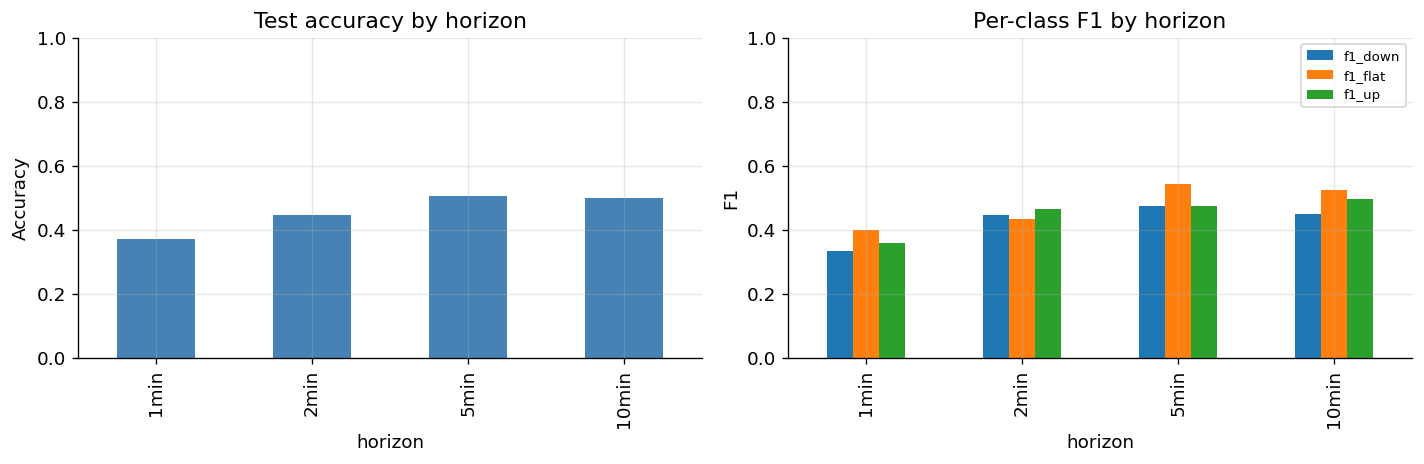

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

metrics_df["accuracy"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Test accuracy by horizon")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)

metrics_df[["f1_down", "f1_flat", "f1_up"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("Per-class F1 by horizon")
axes[1].set_ylabel("F1")
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 4. Confusion Matrices

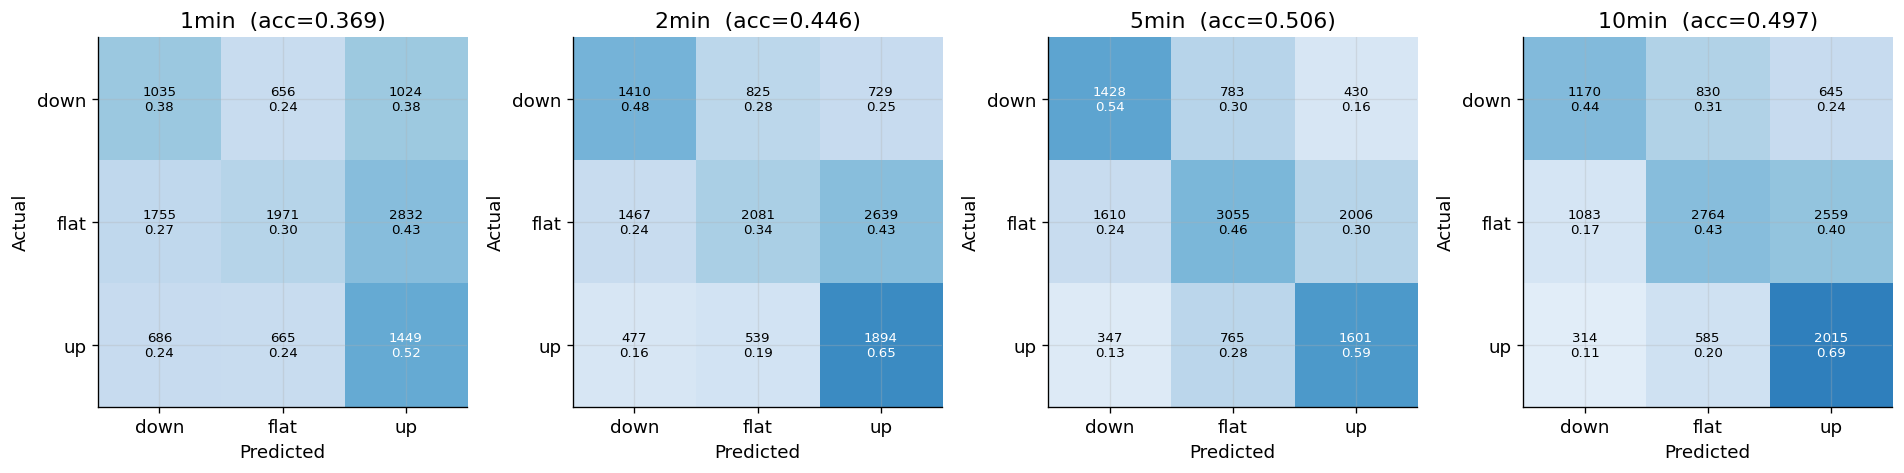

In [5]:
fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 4))

for ax, (label, r) in zip(axes, results.items()):
    cm = np.array(r["metrics"]["confusion_matrix"], dtype=float)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    for i in range(len(CLASS_NAMES)):
        for j in range(len(CLASS_NAMES)):
            ax.text(
                j,
                i,
                f"{int(cm[i, j])}\n{cm_norm[i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if cm_norm[i, j] > 0.5 else "black",
            )
    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(CLASS_NAMES)
    ax.set_yticks(range(len(CLASS_NAMES)))
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{label}  (acc={r['metrics']['accuracy']:.3f})")

plt.tight_layout()
plt.show()

---
## 5. Prediction Time Series

Mid-price over each asset's test period, with each horizon model's predictions
overlaid: **green = predicted up**, **red = predicted down** (flat predictions are
left unmarked).

In [6]:
ASSETS = results[next(iter(results))]["cfg"].data.assets

# raw mid-price + time per asset (identical across horizons: same data, same n_levels)
raw = {}
for sym in ASSETS:
    df = pd.read_csv(f"data/{sym}_orderbook.csv")
    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values("time").reset_index(drop=True)
    raw[sym] = {
        "time": df["time"].to_numpy(),
        "mid": ((df["ask_price_1"] + df["bid_price_1"]) / 2.0).to_numpy(),
    }


def split_bounds(n, cfg):
    n_tr = int(n * cfg.split.train)
    n_val = int(n * cfg.split.val)
    return n_tr + n_val, n  # test split (lo, hi)


# split bounds only depend on data length + split fractions, identical across horizons
ref_cfg = results[next(iter(results))]["cfg"]

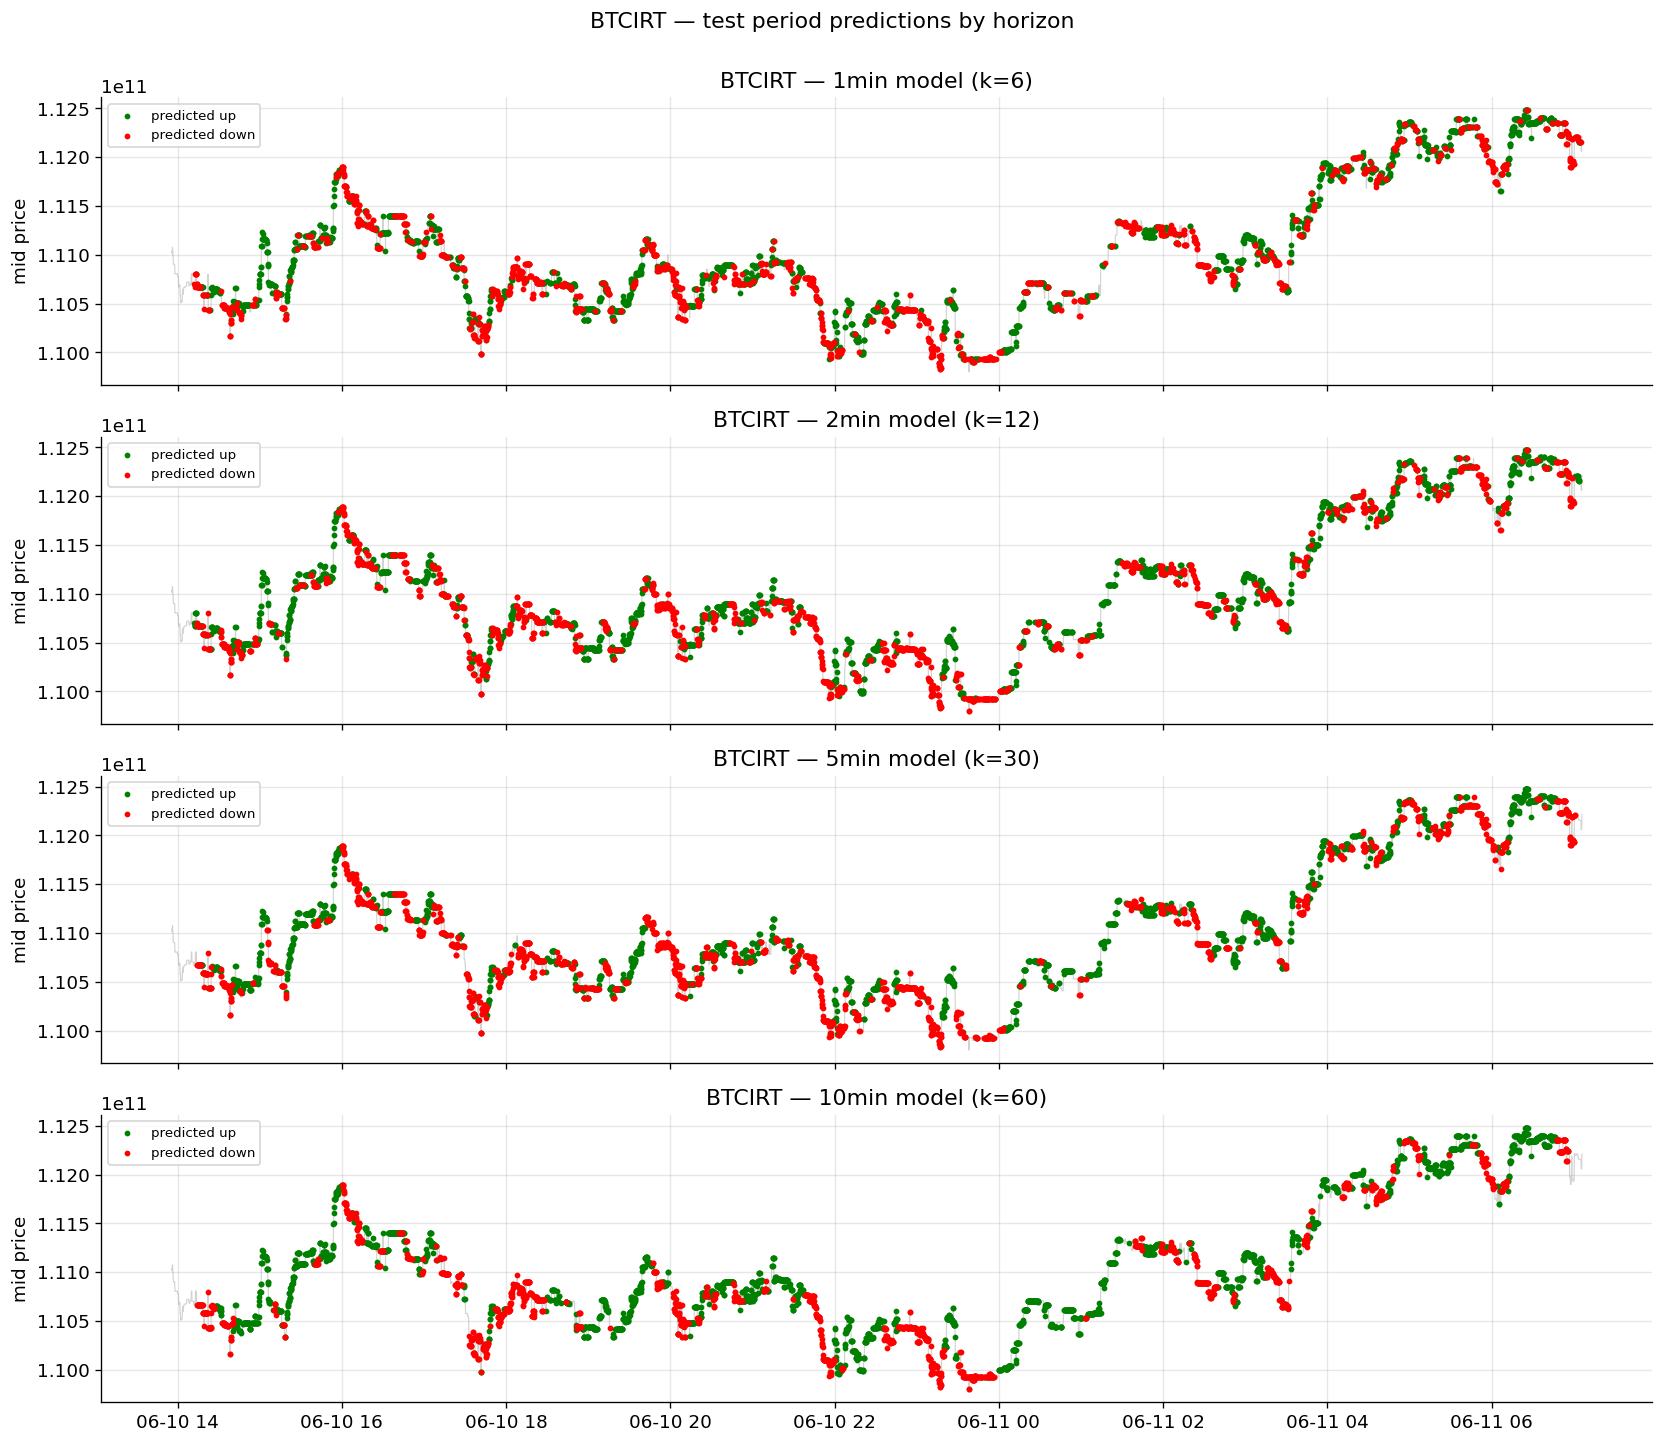

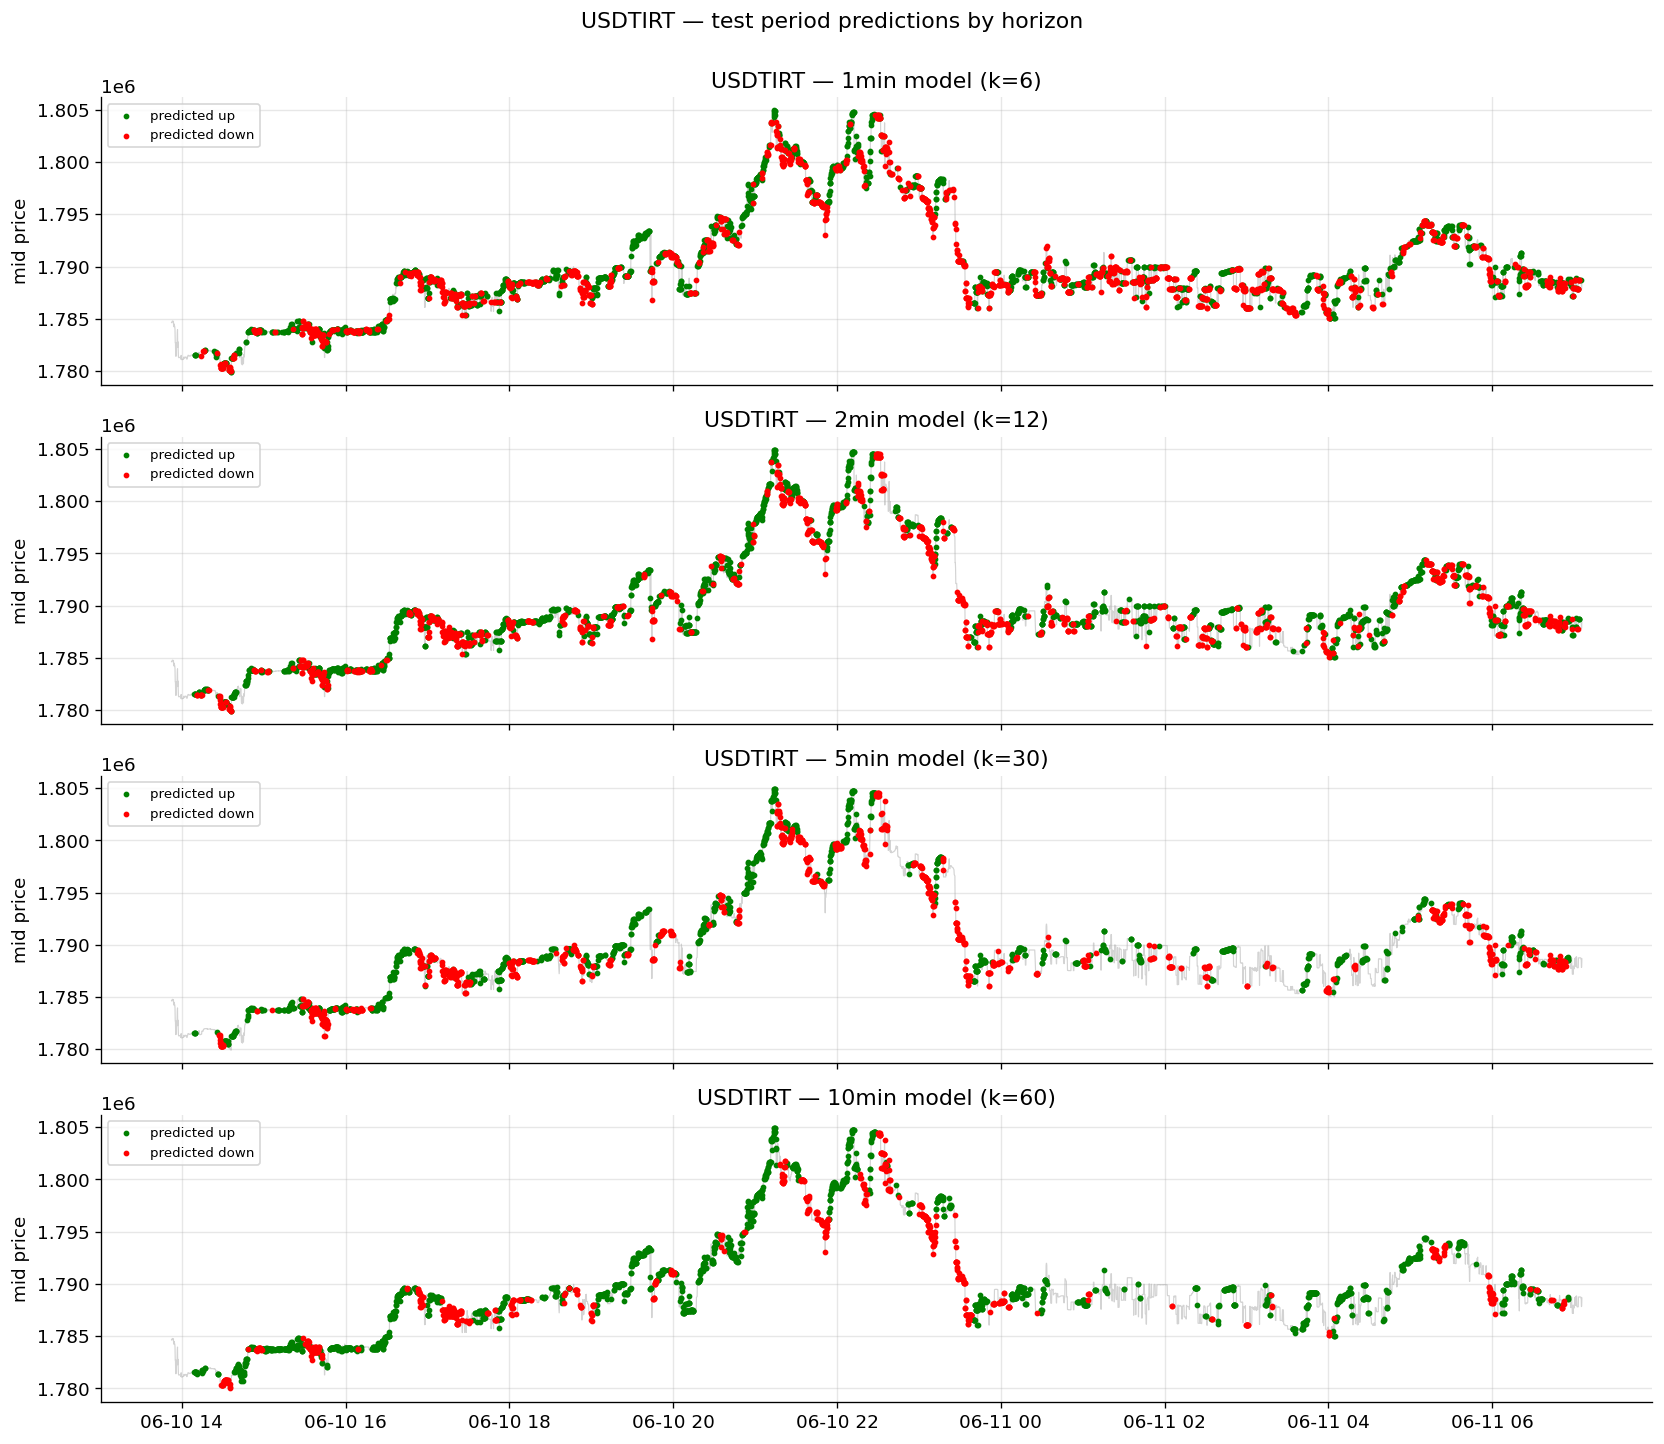

In [7]:
for sym in ASSETS:
    lo, hi = split_bounds(len(raw[sym]["mid"]), ref_cfg)
    time_test, mid_test = raw[sym]["time"][lo:hi], raw[sym]["mid"][lo:hi]

    fig, axes = plt.subplots(
        len(results), 1, figsize=(14, 3 * len(results)), sharex=True
    )
    for ax, (label, r) in zip(axes, results.items()):
        ends = np.array([e for a, e in r["index"] if a == sym])
        preds = np.array([p for (a, _), p in zip(r["index"], r["preds"]) if a == sym])

        ax.plot(time_test, mid_test, color="lightgray", lw=0.7, zorder=1)
        up, down = preds == 2, preds == 0
        ax.scatter(
            raw[sym]["time"][ends[up]],
            raw[sym]["mid"][ends[up]],
            color="green",
            s=6,
            label="predicted up",
            zorder=2,
        )
        ax.scatter(
            raw[sym]["time"][ends[down]],
            raw[sym]["mid"][ends[down]],
            color="red",
            s=6,
            label="predicted down",
            zorder=2,
        )
        ax.set_title(f"{sym} — {label} model (k={r['cfg'].label.horizon_k})")
        ax.set_ylabel("mid price")
        ax.legend(fontsize=8, loc="upper left")

    fig.suptitle(f"{sym} — test period predictions by horizon", y=1.0)
    plt.tight_layout()
    plt.show()

---
## Summary

In [8]:
best_acc = metrics_df["accuracy"].idxmax()
best_f1 = metrics_df["macro_f1"].idxmax()
print(f"Best accuracy : {best_acc} ({metrics_df.loc[best_acc, 'accuracy']:.4f})")
print(f"Best macro-F1 : {best_f1} ({metrics_df.loc[best_f1, 'macro_f1']:.4f})")
metrics_df.round(4)

Best accuracy : 5min (0.5059)
Best macro-F1 : 5min (0.4968)


,k (snapshots),alpha (bps),accuracy,macro_f1,f1_down,f1_flat,f1_up
horizon,,,,,,,
1min,6,2.0,0.3690,0.3640,0.3344,0.4002,0.3576
2min,12,3.0,0.4465,0.4473,0.4463,0.4321,0.4635
5min,30,6.0,0.5059,0.4968,0.4739,0.5420,0.4744
10min,60,8.0,0.4972,0.4889,0.4490,0.5222,0.4955
